# 理论|相似性

部分图片AI生成，仅示意

这是一篇关于“相似性”（Similarity）的系统性整理。在数学、数据科学和机器学习中，衡量两个对象（向量、函数或随机变量）的“相似程度”是核心任务。

从最基础的几何投影，到连续空间的函数分析，再到统计学中的线性与非线性相关，向量的点积，余弦相似性，函数的内积，皮尔逊相似性，斯皮尔曼相似性，这五种相似性指标并非孤立存在，而是遵循着一条**去除干扰因素、逐步提升鲁棒性（Robustness）的演化路径**。

---

### 一、 核心概念解析与演化路径

#### 1. 向量的点积 (Dot Product) —— 相似性的绝对几何起源
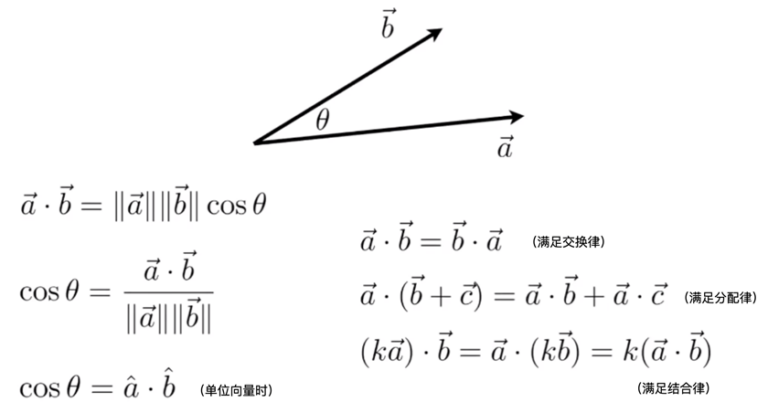
*   **定义**：两个向量对应分量乘积之和。$\vec{A} \cdot \vec{B} = \sum_{i=1}^{n} a_i b_i = |\vec{A}| |\vec{B}| \cos(\theta)$
*   **物理与几何意义**：点积衡量了两个向量在同一方向上的**投影长度与模长的综合影响**。
*   **局限性**：点积的值没有上限。如果两个向量方向完全不一致，但其中一个向量的模长（绝对数值）极大，它们的点积仍然可能很大。它混淆了“方向的相似”与“自身尺度的大小”。

#### 2. 函数的内积 (Inner Product of Functions) —— 相似性向连续空间的升维
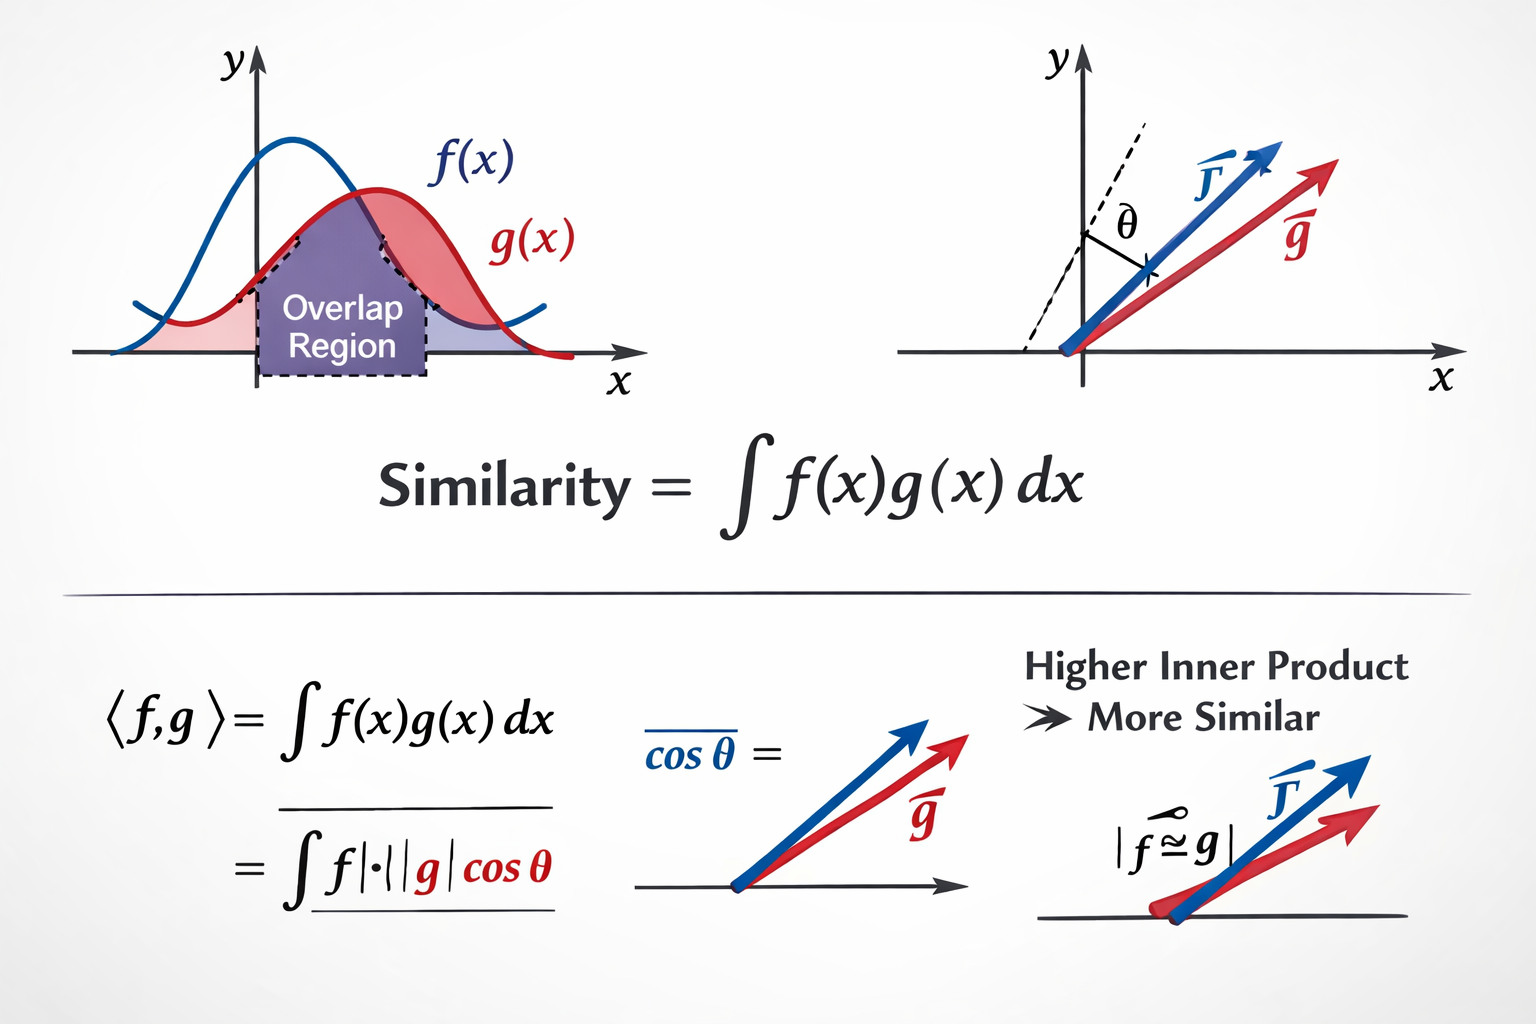
*   **演化逻辑**：将离散向量的点积，推广到无穷维的连续空间（泛函分析与希尔伯特空间）。
*   **定义**：两个函数 $f(x)$ 和 $g(x)$ 在区间 $[a, b]$ 上的内积定义为：$\langle f, g \rangle = \int_{a}^{b} f(x)g(x)dx$
*   **关联**：如果把函数看作是由无数个无穷小的点组成的“连续向量”，积分实际上就是点积求和 $\sum$ 的连续极限。
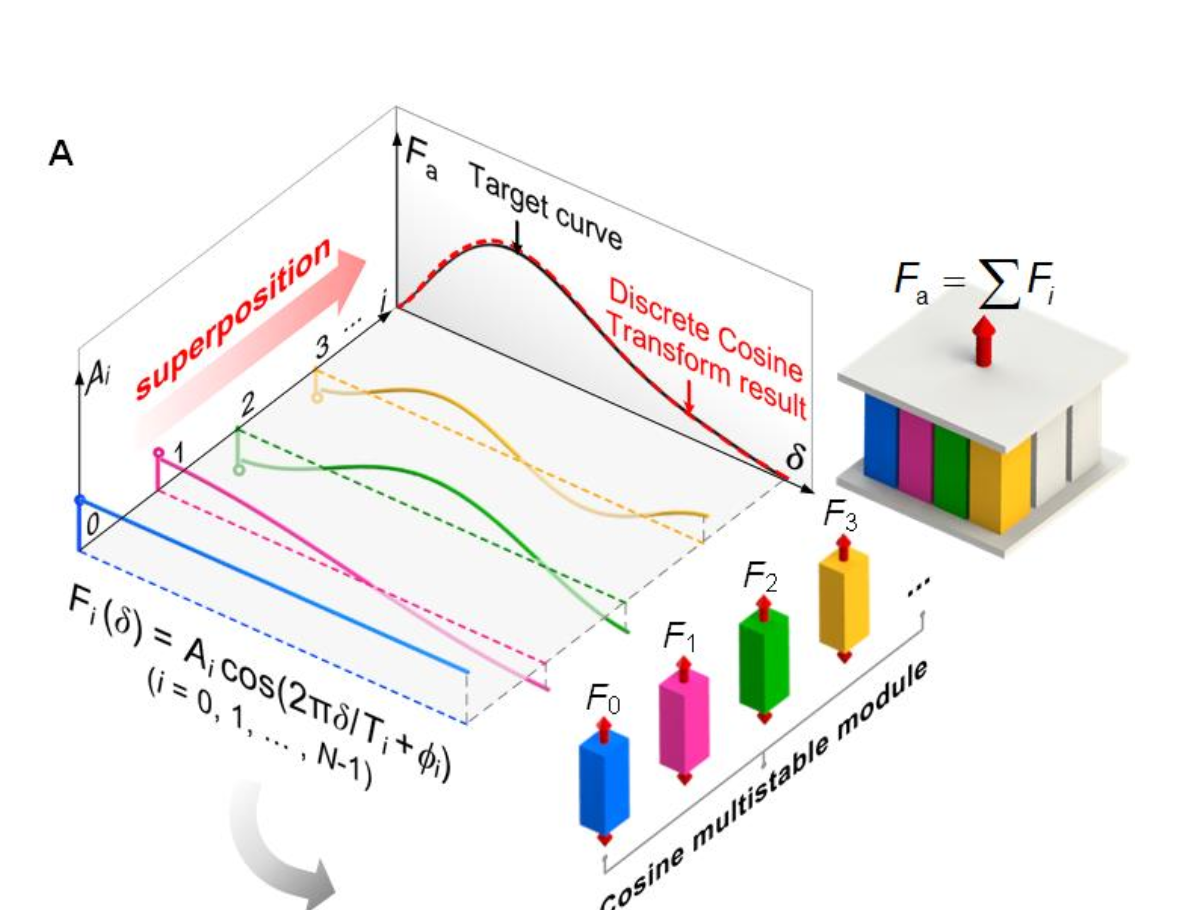
*   **应用**：这是傅里叶变换的核心。通过计算信号函数与正弦/余弦基函数的内积，可以衡量信号中“包含某种频率的相似程度”。

#### 3. 余弦相似性 (Cosine Similarity) —— 剔除尺度（Scale）的纯方向度量
*   **演化逻辑**：为了解决点积受“模长（向量大小）”影响的问题，我们将点积除以两个向量的模长进行**归一化**（Normalization）。
*   **定义**：$\cos(\theta) = \frac{\vec{A} \cdot \vec{B}}{|\vec{A}| |\vec{B}|}$
*   **特性**：取值范围被严格压缩在 $[-1, 1]$ 之间。它**对尺度缩放免疫**（Scale-invariant）。将向量 $A$ 的所有元素乘以 10，它与 $B$ 的余弦相似度不变。
*   **局限性**：它对**平移（Translation/Shift）敏感**。例如，用户对两部电影的评分向量是 $A=(1, 2)$ 和 $B=(4, 5)$，其实评价趋势一致（后者比前者好一点），但因为基准线不同，余弦相似度无法完美体现这种趋势的绝对一致性。

#### 4. 皮尔逊相关系数 (Pearson Correlation) —— 剔除平移（Shift）的线性统计度量
*   **演化逻辑**：为了解决余弦相似度对“数据平移”敏感的问题，我们在计算前，先将数据**中心化（去均值化，Mean-centering）**。
*   **数学关联**：**皮尔逊相关系数，本质上就是中心化后的余弦相似度！**
    设 $\vec{X'} = \vec{X} - \bar{X}$，$\vec{Y'} = \vec{Y} - \bar{Y}$，则：
    $r = \frac{\sum (X_i - \bar{X})(Y_i - \bar{Y})}{\sqrt{\sum (X_i - \bar{X})^2} \sqrt{\sum (Y_i - \bar{Y})^2}} = \frac{\vec{X'} \cdot \vec{Y'}}{|\vec{X'}| |\vec{Y'}|} = \cos(\vec{X'}, \vec{Y'})$
*   **特性**：取值 $[-1, 1]$。它既对尺度缩放免疫，又对平移免疫。它是衡量两个变量**线性相关性**的黄金标准。
*   **局限性**：它要求数据呈线性关系，且对**极端异常值（Outliers）极其敏感**。如果数据是指数级增长的非线性单调关系，皮尔逊相关性会低估其相似度。

#### 5. 斯皮尔曼相关系数 (Spearman Correlation) —— 剔除分布（Distribution）的非参数度量
*   **演化逻辑**：为了克服皮尔逊对异常值的敏感以及只能衡量线性关系的缺陷，斯皮尔曼放弃了数据的“绝对数值”，转而使用数据的**“秩次（Rank，即排名）”**。
*   **数学关联**：**斯皮尔曼相关系数，本质上就是对数据的“排名向量”计算皮尔逊相关系数！**
    将 $X=[10, 20, 3000]$ 和 $Y=[1, 5, 6]$ 转化为排名向量 $R_x=[1, 2, 3]$ 和 $R_y=[1, 2, 3]$，然后再计算 $R_x$ 和 $R_y$ 的皮尔逊系数。
*   **特性**：它可以衡量任何**单调关系**（Monotonicity，只要一个变大另一个也跟着变大即可，不管幅度多夸张）。它对异常值具有极强的免疫力（鲁棒性）。

---

### 二、 系统性对比与总结表格

为了更清晰地呈现它们的异同，我们可以从“它能抵抗什么干扰”这一维度来进行系统对比：

| 相似性度量 | 数学本质（核心动作） | 对尺度缩放免疫？ (乘法操作) | 对数据平移免疫？ (加法操作) | 对非线性单调免疫？ | 对异常值敏感度 | 典型应用场景 |
| :--- | :--- | :---: | :---: | :---: | :--- | :--- |
| **向量点积** | 原始数据的乘积累加 | ❌ 否 | ❌ 否 | ❌ 否 | 极高 | 神经网络的线性层计算，注意力机制 (Attention) |
| **函数内积** | 连续无穷维的点积 | ❌ 否 | ❌ 否 | ❌ 否 | 极高 | 信号处理（傅里叶变换），量子力学概率幅计算 |
| **余弦相似性** | 长度归一化后的点积 | ✅ 是 | ❌ 否 | ❌ 否 | 高 | 文本分析 (TF-IDF)，高维稀疏特征的相似度 (如Word2Vec) |
| **皮尔逊相似** | 去均值化后的余弦相似 | ✅ 是 | ✅ 是 | ❌ 否 | 高 | 连续变量的线性相关性分析，金融资产协方差分析 |
| **斯皮尔曼相似**| 秩次(排名)的皮尔逊相似 | ✅ 是 | ✅ 是 | ✅ 是 | **极低 (鲁棒)** | 非正态分布数据，包含异常值的数据，非线性单调关系的挖掘 |

---

### 三、 概念之间的高维关联映射 (The Big Picture)

这五种概念并不是平行罗列的，它们构成了一个严密的**数学代数结构与统计学的演化网络**：

1.  **从离散到连续的纵向跨越**：
    *   **点积**是有限维欧几里得空间 $R^n$ 的产物。
    *   **函数内积**是将其推向无穷维希尔伯特空间的连续极限 $\int$。

2.  **从几何到统计的横向演化（相似性的提纯史）**：
    *   **Step 1（原始）：** 给定向量 $\vec{X}, \vec{Y}$ $\xrightarrow{\text{直接计算}}$ **点积** （保留了绝对大小和方向）。
    *   **Step 2（剥离大小）：** 除以模长 $\xrightarrow{\text{归一化}}$ **余弦相似度** （只剩下夹角/方向）。
    *   **Step 3（剥离基准）：** 减去均值 $\xrightarrow{\text{中心化}}$ **皮尔逊系数** （只剩下围绕重心的协变趋势）。
    *   **Step 4（剥离分布/数值）：** 转化为排名 $\xrightarrow{\text{非参数化}}$ **斯皮尔曼系数** （只剩下纯粹的单调同步性）。

### 结语

在实际应用（如机器学习或数据分析）中，选择哪种相似性完全取决于你的**数据特性和业务需求**。
如果你关心绝对强度的累加（如物理做功、注意力机制评分），用**点积**；
如果你处理的是连续信号分析，用**函数内积**；
如果你关注高维稀疏向量的方向（如文本、用户画像），用**余弦相似性**；
如果你在做基础的线性统计和回归，用**皮尔逊**；
如果你的数据充满噪音、异常值，或是非线性指数级增长的，**斯皮尔曼**是你最好的防线。